In [11]:
!python -m pip install pandas scikit-learn matplotlib seaborn flaml autogluon h2o

In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"

df = pd.read_csv(url, nrows=5000)
#df = pd.read_csv('модуль 3 - датасет - практика.csv', nrows=5000)
columns = [
    'Count_subj', 'rr_interval', 'p_end', 'qrs_onset',
    'qrs_end', 'p_axis', 'qrs_axis', 't_axis', 'Healthy_Status'
]

df = df[columns]

# 去缺失
df = df.dropna()

X = df.drop('Healthy_Status', axis=1)
y = df['Healthy_Status']


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

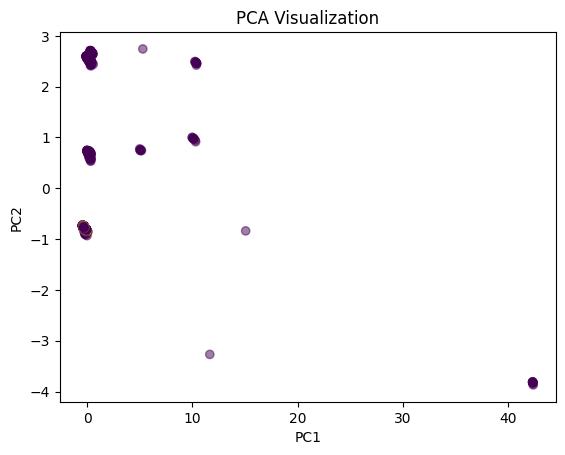

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 标准化特征（PCA对特征尺度敏感，ECG各参数数值范围差异巨大）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.5)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

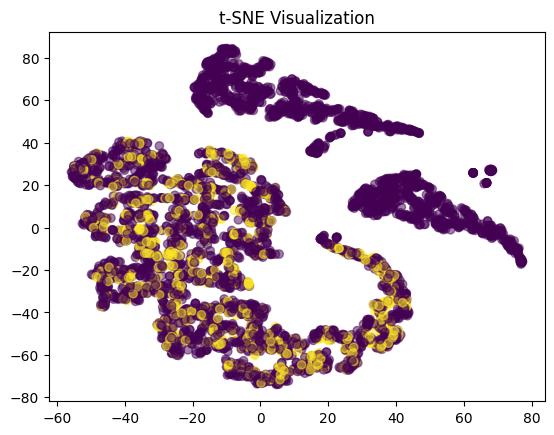

In [15]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 标准化特征（t-SNE对特征尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, alpha=0.5)
plt.title("t-SNE Visualization")
plt.show()

In [16]:
from sklearn.metrics import f1_score, confusion_matrix

In [17]:
from flaml import AutoML

automl = AutoML()

automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="classification",
    time_budget=60,
    metric='macro_f1'
)

y_pred_flaml = automl.predict(X_test)

f1_flaml = f1_score(y_test, y_pred_flaml, average='macro')
print("FLAML Macro F1:", f1_flaml)

[flaml.automl.logger: 04-25 14:21:20] {2375} INFO - task = classification
[flaml.automl.logger: 04-25 14:21:20] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-25 14:21:20] {2489} INFO - Minimizing error metric: 1-macro_f1
[flaml.automl.logger: 04-25 14:21:20] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 04-25 14:21:20] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-25 14:21:20] {3046} INFO - Estimated sufficient time budget=1266s. Estimated necessary time budget=31s.
[flaml.automl.logger: 04-25 14:21:20] {3097} INFO -  at 0.1s,	estimator lgbm's best error=5.5310e-01,	best estimator lgbm's best error=5.5310e-01
[flaml.automl.logger: 04-25 14:21:20] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-25 14:21:20] {3097} INFO -  at 0.3s,	estimator lgbm's best error=5.5310e-01,	best estimator lgbm's best error=5.5310e-01

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 04-25 14:21:20] {3097} INFO -  at 0.5s,	estimator sgd's best error=5.5310e-01,	best estimator lgbm's best error=5.5310e-01
[flaml.automl.logger: 04-25 14:21:20] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 04-25 14:21:21] {3097} INFO -  at 0.6s,	estimator lgbm's best error=5.5310e-01,	best estimator lgbm's best error=5.5310e-01
[flaml.automl.logger: 04-25 14:21:21] {2911} INFO - iteration 5, current learner sgd
[flaml.automl.logger: 04-25 14:21:21] {3097} INFO -  at 0.8s,	estimator sgd's best error=5.5174e-01,	best estimator sgd's best error=5.5174e-01
[flaml.automl.logger: 04-25 14:21:21] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 04-25 14:21:21] {3097} INFO -  at 0.9s,	estimator lgbm's best error=5.5310e-01,	best estimator sgd's best error=5.5174e-01
[flaml.automl.logger: 04-25 14:21:21] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-25 14:21:21] {3097} INFO -  at 1.0s,	estimator lgbm'

In [18]:
from autogluon.tabular import TabularPredictor

train_data = X_train.copy()
train_data['Healthy_Status'] = y_train

test_data = X_test.copy()

predictor = TabularPredictor(
    label='Healthy_Status',
    eval_metric='f1_macro'
).fit(train_data, time_limit=120)

y_pred_ag = predictor.predict(test_data)

f1_ag = f1_score(y_test, y_pred_ag, average='macro')
print("AutoGluon Macro F1:", f1_ag)

No path specified. Models will be saved in: "AutogluonModels\ag-20260425_112220"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          24
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       17.09 GB / 31.71 GB (53.9%)
Disk Space Avail:   43.23 GB / 75.00 GB (57.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra

AutoGluon Macro F1: 0.7826318337928047


In [19]:
from tpot import TPOTClassifier
from sklearn.metrics import f1_score

tpot = TPOTClassifier(
    scorers=['f1_macro'],
    scorers_weights=[1],
    max_time_mins=10,
    verbose=2,
    random_state=42,
    n_jobs=1
)

tpot.fit(X_train, y_train)
y_pred_tpot = tpot.predict(X_test)
f1_tpot = f1_score(y_test, y_pred_tpot, average='macro')
print("TPOT Macro F1:", f1_tpot)


Generation: : 1it [11:32, 692.98s/it]


TPOT Macro F1: 0.7628458498023716


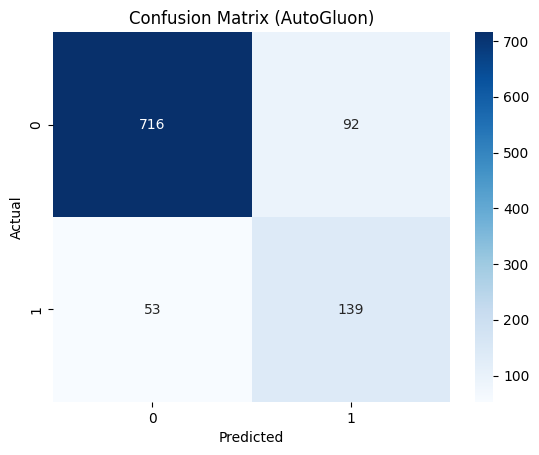

Final Macro F1: 0.7826318337928047


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_ag)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (AutoGluon)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Final Macro F1:", f1_ag)
